# Representation autoencoders, run against the VAE they replace


This is the notebook the atlas most needed. The representation-latent line proposes throwing away
the variational autoencoder and generating inside a frozen vision foundation model instead. That
claim is testable, and the authors released everything required to test it.

We load three representation autoencoders, built on frozen DINOv2, SigLIP 2 and MAE encoders with
trained ViT decoders, and put the same image through each alongside Stable Diffusion's autoencoder.
Then we look at the one result that reframed how this line thinks about tokenizers: the encoder that
reconstructs best is not the encoder that generates best.

Runs in a few minutes on one GPU. Outputs below are from an NVIDIA A100 80GB.


---


**What this notebook uses, and who made it**

| Component | Source |
|---|---|
| RAE implementation and released decoders | [bytetriper/RAE](https://github.com/bytetriper/RAE), [nyu-visionx/RAE-collections](https://huggingface.co/nyu-visionx/RAE-collections) |
| Paper | Zheng, Ma, Tong and Xie, [Diffusion Transformers with Representation Autoencoders](https://arxiv.org/abs/2510.11690), NYU |
| Frozen encoders | [DINOv2 with registers](https://huggingface.co/facebook/dinov2-with-registers-base), [SigLIP 2](https://huggingface.co/google/siglip2-base-patch16-256), [MAE](https://huggingface.co/facebook/vit-mae-base) |
| Stable Diffusion 1.5 autoencoder, for comparison | [runwayml/stable-diffusion-v1-5](https://huggingface.co/runwayml/stable-diffusion-v1-5) |

The RAE code and weights are the authors' own, cloned unmodified to `external/RAE`. This notebook
calls their `RAE.encode` and `RAE.decode` directly and adds nothing to them. Setup instructions are
in `notebooks/README.md`.

Related atlas reading: [the representation-latent line](/lines/line-representation-latent),
[the RAE paper entry](/papers/rae-2025), and the open problem of
[which encoder to build on](/problems#which-encoder-for-generation).


## Setup

The RAE repository and its released checkpoints live outside this repo, since they are the authors'
code rather than ours. See `notebooks/README.md` for the clone and download commands.

In [1]:
import sys, os, torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

RAE_ROOT = Path("../external/RAE").resolve()
assert RAE_ROOT.exists(), f"clone the RAE repo to {RAE_ROOT} first, see notebooks/README.md"

os.chdir(RAE_ROOT)          # the configs use paths relative to the repo root
sys.path.insert(0, str(RAE_ROOT / "src"))

from omegaconf import OmegaConf
from stage1 import RAE

DEV = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEV}", f"| gpu: {torch.cuda.get_device_name(0)}" if DEV == "cuda" else "")

/home/exx/anaconda3/envs/dediffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | gpu: NVIDIA A100 80GB PCIe


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading pipeline components...:  33%|███▎      | 2/6 [00:00<00:00,  4.50it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/196 [00:00<00:00, 867.13it/s, Materializing param=text_model.embeddings.position_embedding.weight]

Loading weights:   1%|          | 1/196 [00:00<00:00, 212.70it/s, Materializing param=text_model.embeddings.position_embedding.weight]

...

Loading weights: 100%|██████████| 196/196 [00:00<00:00, 214.81it/s, Materializing param=text_model.final_layer_norm.weight]

CLIPTextModel LOAD REPORT from: /home/exx/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading pipeline components...:  67%|██████▋   | 4/6 [00:01<00:00,  2.44it/s]

Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  3.71it/s]


You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


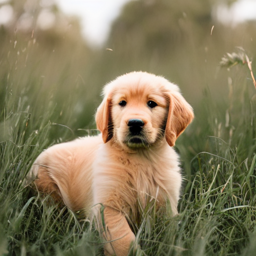

In [2]:
# A test image, generated so the notebook carries no data dependency. It deliberately
# contains fine texture and small structure, which is where autoencoders lose information.
from diffusers import StableDiffusionPipeline

sd = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16,
    safety_checker=None, local_files_only=True,
).to(DEV)
sd.set_progress_bar_config(disable=True)

g = torch.Generator(DEV).manual_seed(11)
source = sd("a golden retriever puppy sitting in tall grass, detailed fur, "
            "shallow depth of field, photograph", num_inference_steps=30, generator=g).images[0]
source = source.resize((256, 256))
source

## Loading three representation autoencoders

Each is a frozen encoder with a trained ViT-XL decoder. Nothing about the encoder is learned for
this task; the entire burden of getting back to pixels falls on the decoder.

Note what comes back from `encode`. Stable Diffusion's autoencoder gives a 4-channel latent on a
64x64 grid. These give a 768-channel latent on a 16x16 grid. Same image, roughly three times as many
numbers, arranged completely differently.

In [3]:
CONFIGS = {
    "RAE / DINOv2-B":  "configs/stage1/pretrained/DINOv2-B.yaml",
    "RAE / SigLIP2-B": "configs/stage1/pretrained/SigLIP2.yaml",
    "RAE / MAE-B":     "configs/stage1/pretrained/MAE.yaml",
}

def load_rae(cfg_path):
    cfg = OmegaConf.load(cfg_path)
    return RAE(**dict(cfg.stage_1.params)).eval().to(DEV)

@torch.no_grad()
def rae_roundtrip(model, img):
    # RAE normalizes with an image-processor mean and std, which assumes [0, 1] input,
    # and decode returns [0, 1]. This differs from the [-1, 1] convention diffusers uses,
    # and getting it wrong costs about 8 dB.
    x = torch.from_numpy(np.array(img)).float() / 255.0
    x = x.permute(2, 0, 1).unsqueeze(0).to(DEV)
    z = model.encode(x)                       # resizes internally to the encoder's input size
    y = model.decode(z)
    y = (y.float().clamp(0, 1) * 255).round().byte()
    y = Image.fromarray(y.squeeze(0).permute(1, 2, 0).cpu().numpy())
    return y.resize(img.size), tuple(z.shape[1:])

def psnr(a, b):
    a, b = np.asarray(a, np.float64), np.asarray(b, np.float64)
    mse = ((a - b) ** 2).mean()
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

results = {}
for name, cfg in CONFIGS.items():
    m = load_rae(cfg)
    rec, shape = rae_roundtrip(m, source)
    results[name] = {"rec": rec, "shape": shape, "psnr": psnr(source, rec)}
    print(f"{name:18s} latent {str(shape):18s} PSNR {results[name]['psnr']:.2f} dB")
    del m; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/224 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/224 [00:00<00:00, 45590.26it/s, Materializing param=embeddings.cls_token]

Loading weights:   0%|          | 1/224 [00:00<00:00, 849.05it/s, Materializing param=embeddings.cls_token]  

Loading weights:   1%|          | 2/224 [00:00<00:00, 779.54it/s, Materializing param=embeddings.mask_token]

Loading weights:   1%|          | 2/224 [00:00<00:00, 671.14it/s, Materializing param=embeddings.mask_token]

...

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


encoder_config_path: facebook/vit-mae-base


Loading pretrained decoder from models/decoders/mae/base_p16/ViTXL_n08/model.pt


Loaded normalization stats from models/stats/mae/base_p16/ImageNet1k/stat.pt


RAE / MAE-B        latent (768, 16, 16)      PSNR 29.49 dB


In [4]:
# The incumbent, for comparison: Stable Diffusion's variational autoencoder.
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained(
    "runwayml/stable-diffusion-v1-5", subfolder="vae",
    torch_dtype=torch.float32, local_files_only=True).to(DEV).eval()

with torch.no_grad():
    x = torch.from_numpy(np.array(source)).float() / 127.5 - 1.0
    x = x.permute(2, 0, 1).unsqueeze(0).to(DEV)
    z = vae.encode(x).latent_dist.mean
    y = vae.decode(z).sample
y = ((y.float().clamp(-1, 1) + 1) * 127.5).round().byte()
sd_rec = Image.fromarray(y.squeeze(0).permute(1, 2, 0).cpu().numpy())
results["SD 1.5 VAE"] = {"rec": sd_rec, "shape": tuple(z.shape[1:]), "psnr": psnr(source, sd_rec)}
print(f"{'SD 1.5 VAE':18s} latent {str(tuple(z.shape[1:])):18s} PSNR {results['SD 1.5 VAE']['psnr']:.2f} dB")

print("\nnumbers in each latent, for one 256x256 image:")
for n, r in results.items():
    print(f"  {n:18s} {np.prod(r['shape']):>8,d}   {r['shape']}")
del vae; torch.cuda.empty_cache()

/home/exx/anaconda3/envs/dediffusion/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


SD 1.5 VAE         latent (4, 32, 32)        PSNR 25.04 dB

numbers in each latent, for one 256x256 image:
  RAE / DINOv2-B      196,608   (768, 16, 16)
  RAE / SigLIP2-B     196,608   (768, 16, 16)
  RAE / MAE-B         196,608   (768, 16, 16)
  SD 1.5 VAE            4,096   (4, 32, 32)


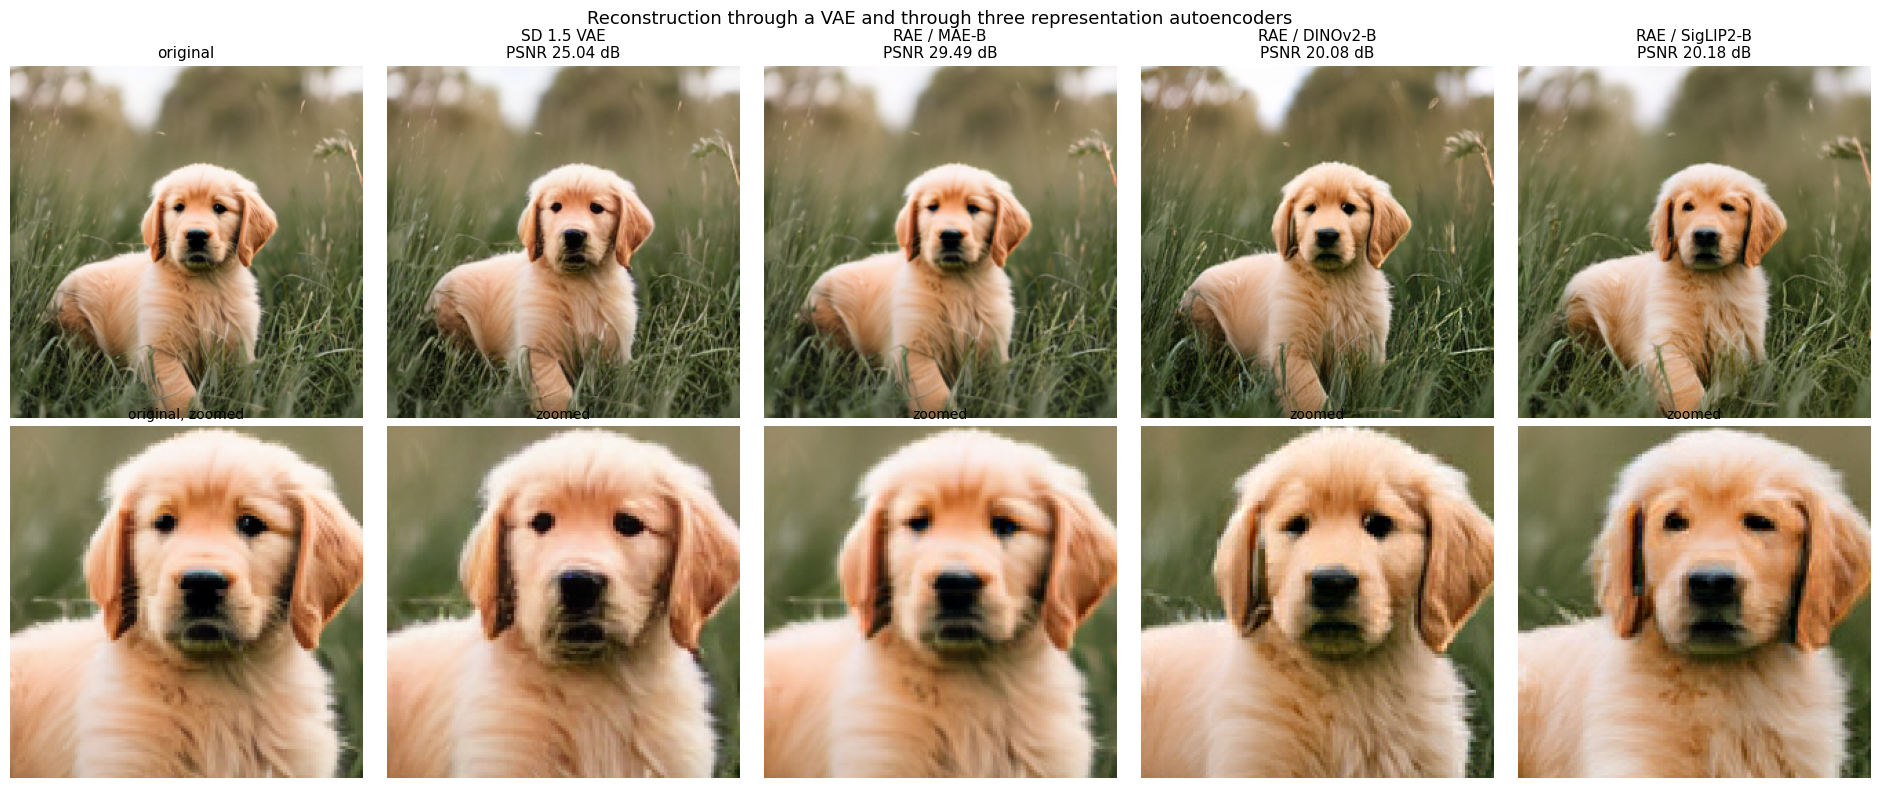

In [5]:
order = ["SD 1.5 VAE", "RAE / MAE-B", "RAE / DINOv2-B", "RAE / SigLIP2-B"]
CROP = (70, 70, 190, 190)

fig, axes = plt.subplots(2, 5, figsize=(19, 8))
axes[0, 0].imshow(source); axes[0, 0].set_title("original", fontsize=11)
axes[1, 0].imshow(source.crop(CROP).resize((256, 256), Image.NEAREST))
axes[1, 0].set_title("original, zoomed", fontsize=10)

for i, name in enumerate(order, start=1):
    r = results[name]
    axes[0, i].imshow(r["rec"])
    axes[0, i].set_title(f"{name}\nPSNR {r['psnr']:.2f} dB", fontsize=11)
    axes[1, i].imshow(r["rec"].crop(CROP).resize((256, 256), Image.NEAREST))
    axes[1, i].set_title("zoomed", fontsize=10)

for ax in axes.ravel(): ax.axis("off")
plt.suptitle("Reconstruction through a VAE and through three representation autoencoders", fontsize=13)
plt.tight_layout(); plt.show()

## Three metrics, three different winners

Read the numbers above alongside what the RAE paper reports over the full ImageNet validation set.

| | our PSNR, one image | paper's rFID, full set | paper's linear probe | best for generation? |
|---|---|---|---|---|
| RAE / MAE-B | **29.5 dB**, best | **0.16**, best | 68.0% | no |
| SD 1.5 VAE | 25.0 dB | 0.62, worst | 8% | no |
| RAE / SigLIP2-B | 20.2 dB | 0.53 | 79.1% | no |
| RAE / DINOv2-B | 20.1 dB, worst | 0.49 | **84.5%**, best | **yes** |

Three things are worth pulling out.

MAE wins reconstruction on both measures, comfortably, and it beats the variational autoencoder even
on the metric that should flatter a VAE. So a frozen encoder that was never trained for this task can
be reconstructed from better than a purpose-built autoencoder can, once you train a good enough
decoder.

DINOv2 and SigLIP2 come last on our PSNR but ahead of the VAE on the paper's rFID. That inversion is
not noise. PSNR rewards pixel-exactness, while these decoders are trained with perceptual and
adversarial losses that deliberately synthesize plausible texture instead of hedging toward a blurry
average. Look at the fur in the zoomed row above: the RAE reconstructions invent strands that are not
in the same places as the original, which reads as detail to a person and as error to PSNR.

And then the finding that reframed the line. **DINOv2 produces the best generation despite ranking
last here and second on rFID.** The encoder that reconstructs best is not the encoder that generates
best.

Reconstruction quality does not predict generation quality. The tokenizer's job is not to be a good
compressor. That dissociation is why this line exists, and why which encoder to build on is still
[an open question](/problems#which-encoder-for-generation) rather than a settled one.

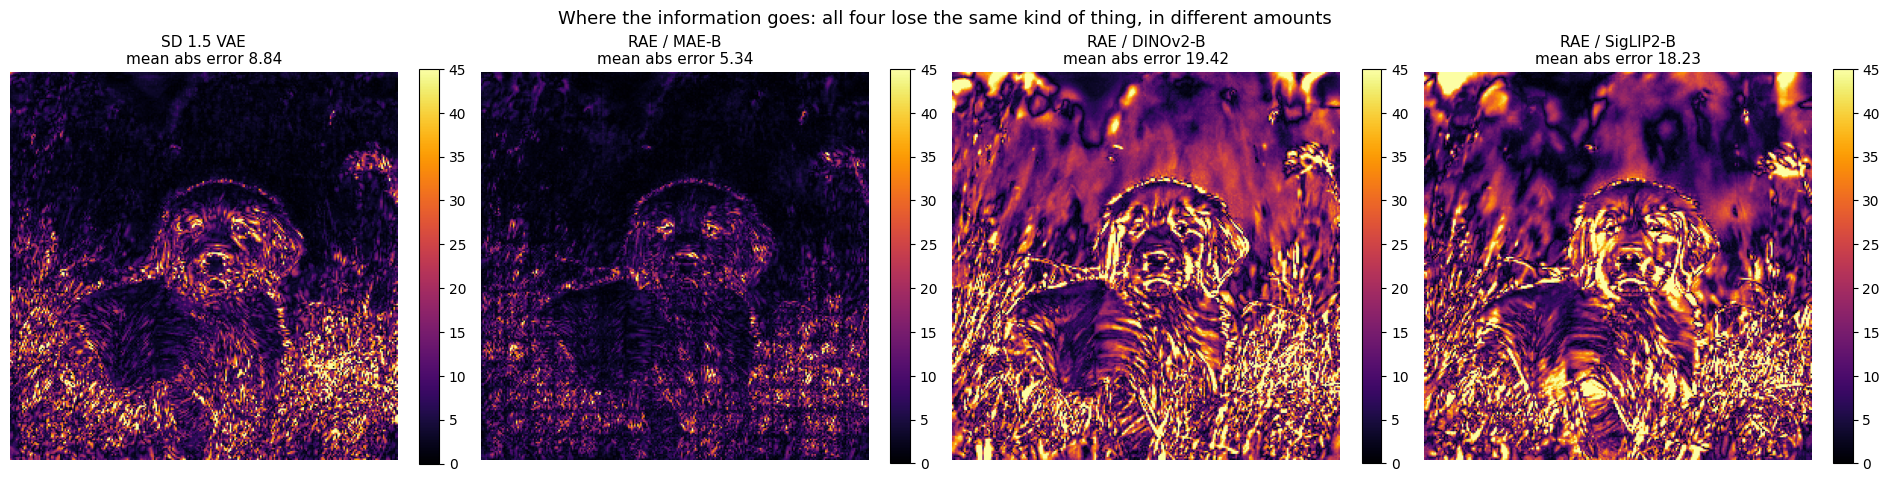

In [6]:
# Where does each one lose information? Same scale for all four.
fig, axes = plt.subplots(1, 4, figsize=(19, 5))
for ax, name in zip(axes, order):
    d = np.abs(np.asarray(source, np.float64)
               - np.asarray(results[name]["rec"], np.float64)).mean(axis=2)
    im = ax.imshow(d, cmap="inferno", vmin=0, vmax=45)
    ax.set_title(f"{name}\nmean abs error {d.mean():.2f}", fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Where the information goes: all four lose the same kind of thing, in different amounts",
             fontsize=13)
plt.tight_layout(); plt.show()

## What the latent actually looks like

A representation autoencoder's latent is not a small picture. Projecting its channels down to three
dimensions shows an organisation by content rather than by appearance, which is precisely what makes
it attractive to generate in and precisely why the decoder has to work so hard.

Loading weights:   0%|          | 0/224 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/224 [00:00<00:00, 45590.26it/s, Materializing param=embeddings.cls_token]

Loading weights:   0%|          | 1/224 [00:00<00:00, 557.75it/s, Materializing param=embeddings.cls_token]  

Loading weights:   1%|          | 2/224 [00:00<00:00, 587.48it/s, Materializing param=embeddings.mask_token]

Loading weights:   1%|          | 2/224 [00:00<00:00, 443.47it/s, Materializing param=embeddings.mask_token]

...

Loading weights: 100%|██████████| 224/224 [00:00<00:00, 504.68it/s, Materializing param=layernorm.weight]

Loading weights: 100%|██████████| 224/224 [00:00<00:00, 496.16it/s, Materializing param=layernorm.weight]

encoder_config_path: facebook/dinov2-with-registers-base


Loading pretrained decoder from models/decoders/dinov2/wReg_base/ViTXL_n08/model.pt


Loaded normalization stats from models/stats/dinov2/wReg_base/imagenet1k/stat.pt


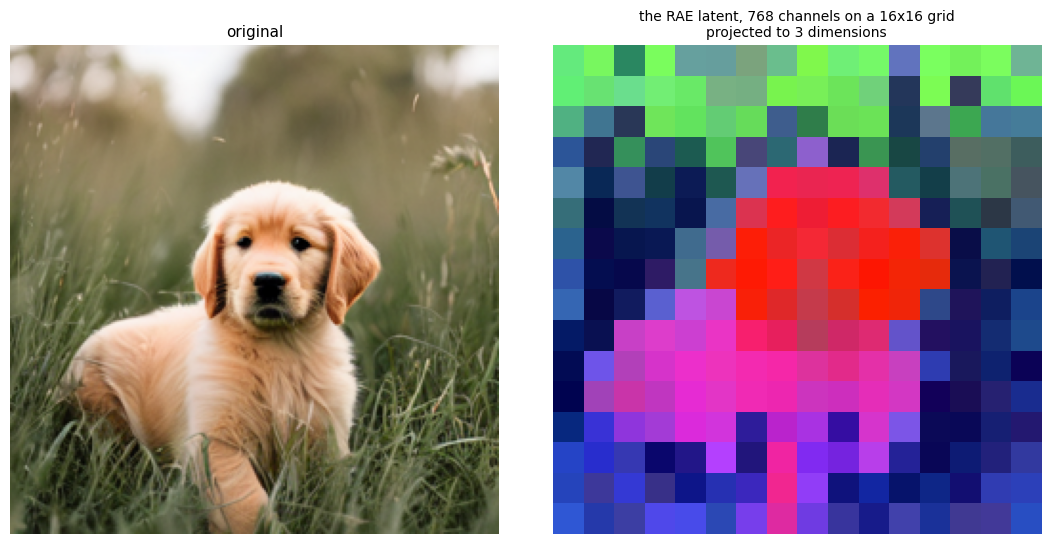

In [7]:
m = load_rae(CONFIGS["RAE / DINOv2-B"])
with torch.no_grad():
    size = m.encoder_input_size
    x = torch.from_numpy(np.array(source.resize((size, size)))).float() / 127.5 - 1.0
    z = m.encode(x.permute(2, 0, 1).unsqueeze(0).to(DEV))

f = z[0].float().cpu().numpy().reshape(z.shape[1], -1).T      # (tokens, channels)
f = (f - f.mean(0)) / (f.std(0) + 1e-6)
_, _, vt = np.linalg.svd(f, full_matrices=False)
proj = f @ vt[:3].T
proj = (proj - proj.min(0)) / (np.ptp(proj, axis=0) + 1e-6)
side = int(np.sqrt(proj.shape[0]))

fig, axes = plt.subplots(1, 2, figsize=(11, 5.4))
axes[0].imshow(source); axes[0].set_title("original", fontsize=11)
axes[1].imshow(proj.reshape(side, side, 3))
axes[1].set_title(f"the RAE latent, {z.shape[1]} channels on a {side}x{side} grid\n"
                  "projected to 3 dimensions", fontsize=10)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
del m; torch.cuda.empty_cache()

## What to take away

- A representation autoencoder is not a smaller latent. It is a wider one: 768 channels on a 16x16
  grid, roughly three times the numbers Stable Diffusion's 4-channel latent uses for the same image.
  That is why the RAE paper had to change the noise schedule and widen the model before diffusion
  would train in it at all.
- The encoder is frozen and was never trained to reconstruct anything. Every bit of pixel fidelity
  you see above comes from the decoder alone.
- The encoder that reconstructs best is not the encoder that generates best. MAE wins reconstruction
  on both metrics we can see here and still loses generation to DINOv2. That dissociation is the
  finding, and it is why reconstruction FID is a misleading target for tokenizer design.
- Metrics disagree with each other, not just with intuition. PSNR ranks DINOv2 last while the paper's
  rFID ranks it second and its generation results rank it first. Any single number would have told
  you something false.

What this notebook does not do is generation, which needs the stage-2 diffusion transformer and a
sampling run. The released weights for that are in the same collection, under `DiTs/`, and that is
the obvious next notebook.

See [the representation-latent line](/lines/line-representation-latent) for the full argument, and
[the comparison page](/compare) for why the published FID numbers cannot rank these approaches
against each other.